In [ ]:
#importamos librerias y dependencias y las configuraciones
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os

#opciones para la visualizacion de las tablas
pd.set_option('display.max_columns', None)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

#configuracion de graficos
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

#gestion de warning
warnings.filterwarnings('ignore')

print("Configuración del entorno\n")
print(f"Pandas: {pd.__version__}")
print(f"Numpy: {np.__version__}")
print(f"Matplotlib: {plt.matplotlib.__version__}")
print(f"Seaborn: {sns.__version__}")

Configuración del entorno

Pandas: 2.2.2
Numpy: 2.0.2
Matplotlib: 3.10.0
Seaborn: 0.13.2


In [ ]:
#conectamos con DRIVE para cargar el dataset
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Ruta de acceso del dataset
#project_folder_path = '/content/drive/MyDrive/PROYECTO TFM IA_BG_E1'

# dataset = '/content/drive/MyDrive/colab-notebooks/Linkia_Master_IA/M6_Proyecto final/data_ramon_v02_regresion_ventas.csv'
#dataset = '/content/data_v07_con_fechas_regresion_devoluciones.csv'

dataset = '/content/drive/MyDrive/colab-notebooks/Linkia_Master_IA/M6_Proyecto final/data_v07_con_fechas_regresion_devoluciones.csv'


In [ ]:
#cargamos el dataset y mostramos las primeras filas
try:
    df = pd.read_csv(dataset, encoding="ISO-8859-1")
    print(f"Archivo {dataset} cargado exitosamente.")
    display(df.head())
except FileNotFoundError:
    print(f"Error: No se encontró el archivo en la ruta: {dataset}")
except Exception as e:
    print(f"Ocurrió un error al cargar el archivo: {e}")

Archivo /content/drive/MyDrive/colab-notebooks/Linkia_Master_IA/M6_Proyecto final/data_v07_con_fechas_regresion_devoluciones.csv cargado exitosamente.


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceDay,InvoiceMonth,InvoiceYear,InvoiceHour,DayOfWeek,IsUk,TotalPrice
0,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,"15,311.00",United Kingdom,1,12,2010,9,2,1,-4.65
1,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,"17,548.00",United Kingdom,1,12,2010,10,2,1,-19.80
2,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,"17,548.00",United Kingdom,1,12,2010,10,2,1,-6.96
3,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,"17,548.00",United Kingdom,1,12,2010,10,2,1,-6.96
4,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,0.29,"17,548.00",United Kingdom,1,12,2010,10,2,1,-6.96


In [ ]:
#Vista general del dataset

#Dimensiones de dataset
print("Dimensiones del dataset:")
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

#Nombres de las columnas.
print("\nNombres de las columnas:")
print(df.columns)

#Primeras y ultimas 5 filas del dataset
print("\nPrimeras 5 filas del dataset:")
display(df.head())
print("\nUltimas 5 filas del dataset:")
display(df.tail())

#tipos de datos y estructura
print("\nTipos de datos y estructura del dataset:")
display(df.info())

#resumen estadistico
print("\nResumen estadístico del dataset:")
display(df.describe())

#resumen descriptivo
print("\nResumen descriptivo del dataset:")
display(df.describe(include='object'))



Dimensiones del dataset:
Filas: 8108
Columnas: 15

Nombres de las columnas:
Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country',
       'InvoiceDay', 'InvoiceMonth', 'InvoiceYear', 'InvoiceHour', 'DayOfWeek', 'IsUk', 'TotalPrice'],
      dtype='object')

Primeras 5 filas del dataset:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceDay,InvoiceMonth,InvoiceYear,InvoiceHour,DayOfWeek,IsUk,TotalPrice
0,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,"15,311.00",United Kingdom,1,12,2010,9,2,1,-4.65
1,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,"17,548.00",United Kingdom,1,12,2010,10,2,1,-19.80
2,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,"17,548.00",United Kingdom,1,12,2010,10,2,1,-6.96
3,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,"17,548.00",United Kingdom,1,12,2010,10,2,1,-6.96
4,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,0.29,"17,548.00",United Kingdom,1,12,2010,10,2,1,-6.96



Ultimas 5 filas del dataset:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceDay,InvoiceMonth,InvoiceYear,InvoiceHour,DayOfWeek,IsUk,TotalPrice
8103,C581490,22178,VICTORIAN GLASS HANGING T-LIGHT,-12,2011-12-09 09:57:00,1.95,"14,397.00",United Kingdom,9,12,2011,9,4,1,-23.40
8104,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,"14,397.00",United Kingdom,9,12,2011,9,4,1,-9.13
8105,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,"15,311.00",United Kingdom,9,12,2011,11,4,1,-54.75
8106,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,"17,315.00",United Kingdom,9,12,2011,11,4,1,-1.25
8107,C581569,20979,36 PENCILS TUBE RED RETROSPOT,-5,2011-12-09 11:58:00,1.25,"17,315.00",United Kingdom,9,12,2011,11,4,1,-6.25



Tipos de datos y estructura del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8108 entries, 0 to 8107
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   InvoiceNo     8108 non-null   object 
 1   StockCode     8108 non-null   object 
 2   Description   8108 non-null   object 
 3   Quantity      8108 non-null   int64  
 4   InvoiceDate   8108 non-null   object 
 5   UnitPrice     8108 non-null   float64
 6   CustomerID    7954 non-null   float64
 7   Country       8108 non-null   object 
 8   InvoiceDay    8108 non-null   int64  
 9   InvoiceMonth  8108 non-null   int64  
 10  InvoiceYear   8108 non-null   int64  
 11  InvoiceHour   8108 non-null   int64  
 12  DayOfWeek     8108 non-null   int64  
 13  IsUk          8108 non-null   int64  
 14  TotalPrice    8108 non-null   float64
dtypes: float64(3), int64(7), object(5)
memory usage: 950.3+ KB


None


Resumen estadístico del dataset:


,Quantity,UnitPrice,CustomerID,InvoiceDay,InvoiceMonth,InvoiceYear,InvoiceHour,DayOfWeek,IsUk,TotalPrice
count,"8,108.00","8,108.00","7,954.00","8,108.00","8,108.00","8,108.00","8,108.00","8,108.00","8,108.00","8,108.00"
mean,-11.88,4.44,"15,005.88",14.88,7.28,"2,010.92",13.20,2.24,0.85,-24.11
std,123.50,8.89,"1,708.58",8.69,3.55,0.27,2.76,1.55,0.36,146.75
min,"-9,360.00",0.03,"12,352.00",1.00,1.00,"2,010.00",6.00,0.00,0.00,"-6,539.40"
25%,-6.00,1.45,"13,534.00",7.00,4.00,"2,011.00",11.00,1.00,1.00,-15.81
50%,-2.00,2.89,"14,895.00",14.00,8.00,"2,011.00",13.00,2.00,1.00,-7.95
75%,-1.00,4.95,"16,422.00",22.00,10.00,"2,011.00",15.00,3.00,1.00,-3.25
max,-1.00,295.00,"18,282.00",31.00,12.00,"2,011.00",20.00,6.00,1.00,-0.12



Resumen descriptivo del dataset:


,InvoiceNo,StockCode,Description,InvoiceDate,Country
count,8108,8108,8108,8108,8108
unique,3299,1863,1888,3244,28
top,C570867,22423,REGENCY CAKESTAND 3 TIER,2011-10-12 16:17:00,United Kingdom
freq,101,172,172,101,6891


In [ ]:
df.shape[0]

8108

# Preprocesado y transformación de datos

necesitamos transformar el dataset de transacciones individuales en un dataset de ventas diarias antes de entrenar cualquier modelo.

Aquí tienes la estrategia y el código para preparar los datos y ejecutar el benchmark final:

**1. Preparación del Dataset Diario (Agregación)**

Primero, debemos convertir las miles de filas de transacciones en una serie de aproximadamente **374 puntos** (los días que hay entre diciembre 2010 y diciembre 2011).


In [ ]:
import pandas as pd
import numpy as np

# Rangos exactos de tu proyecto
start_train = '2010-12-01'
end_train   = '2011-11-08'
start_val   = '2011-10-09'
end_val     = '2011-11-08'
start_test  = '2011-11-09'
end_test    = '2011-12-09'

def preprocess_returns_for_rf(df, target_col='TotalPrice'):
    # Convertir a valor absoluto para predecir "Volumen de Devolución"
    df[target_col] = df[target_col].abs()

    # Asegurar formato fecha y agrupar por día
    df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate']).dt.normalize()
    df_daily = df.groupby('InvoiceDate')[target_col].sum().reset_index()
    df_daily.columns = ['date', 'daily_returns']

    # Rellenar los días sin devoluciones con ceros, para que al hacer lag_1 tome como referencia el día de antes (ya que si no se han hecho devoluciones en un día, tomaría como día anterior el último día en el que se realizó alguna devolución)
    df_daily.set_index('date', inplace=True)

    idx = pd.date_range(start=df_daily.index.min(), end=df_daily.index.max())
    df_daily = df_daily.reindex(idx, fill_value=0)
    df_daily = df_daily.reset_index().rename(columns={'index': 'date'})

    # FEATURE ENGINEERING (Ingeniería de Características)
    df_daily['month'] = df_daily['date'].dt.month
    df_daily['day_of_month'] = df_daily['date'].dt.day
    df_daily['day_of_week'] = df_daily['date'].dt.dayofweek
    df_daily['is_weekend'] = (df_daily['day_of_week'] >= 5).astype(int)

    # Variables de "Memoria" (Lags de devoluciones)
    df_daily['returns_lag_1'] = df_daily['daily_returns'].shift(1)
    df_daily['returns_lag_7'] = df_daily['daily_returns'].shift(7)
    df_daily.bfill(inplace=True) # Rellenamos los primeros días NaN

    # División de conjuntos (Train, Val, Test)
    df_train = df_daily[(df_daily['date'] >= start_train) & (df_daily['date'] <= end_train)].copy()
    df_val   = df_daily[(df_daily['date'] >= start_val)   & (df_daily['date'] <= end_val)].copy()
    df_test  = df_daily[(df_daily['date'] >= start_test)  & (df_daily['date'] <= end_test)].copy()

    print(f" ==== Reporte de Datos de DEVOLUCIONES: ====== ")
    print(f"   - Entrenamiento: {len(df_train)} días")
    print(f"   - Test Final:    {len(df_test)} días")
    print(f"   - Días con 0 devoluciones detectados y rellenados: {(df_daily['daily_returns'] == 0).sum()}")

    return df_train, df_val, df_test

# Ejecutamos asumiendo que tu dataset de devoluciones está en dfc_devoluciones
df_train, df_val, df_test = preprocess_returns_for_rf(df, 'TotalPrice')

 ==== Reporte de Datos de DEVOLUCIONES: ====== 
   - Entrenamiento: 343 días
   - Test Final:    31 días
   - Días con 0 devoluciones detectados y rellenados: 72


## Modelo: Prophet

Prophet no usa las columnas de features, solo la fecha y el target.

In [ ]:
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def train_predict_prophet(df_train, df_test, target, date, prophet_model, nombre_exp="Prophet"):
    # 1. Preparar datos (Prophet es estricto con los nombres)
    train_prophet = df_train.rename(columns={date: 'ds', target: 'y'})

    # 2. Entrenar
    model = prophet_model

    model.add_regressor('month')
    model.add_regressor('day_of_month')
    model.add_regressor('day_of_week')
    model.add_regressor('is_weekend')

    model.add_regressor('returns_lag_1')
    model.add_regressor('returns_lag_7')
    #model.add_regressor('rolling_mean_7')
    #model.add_regressor('rolling_mean_30')

    model.fit(train_prophet)

    # 3. Predecir (le pasamos los días del dataframe de test)
    test_prophet = df_test.rename(columns={date: 'ds'})
    # Pass all regressor columns to the predict method

    forecast = model.predict(test_prophet[['ds', 'month', 'day_of_month', 'day_of_week', 'is_weekend', 'returns_lag_1', 'returns_lag_7']])
    #forecast = model.predict(test_prophet[['ds', 'month', 'day_of_month', 'day_of_week', 'is_weekend']])




    # El resultado está en la columna 'yhat'
    preds = forecast['yhat']

    # Create a modified df_test to add prediction columns
    df_test_modified = df_test.copy()
    df_test_modified['predicted_returns'] = preds.values
    df_test_modified['actual_returns'] = df_test_modified[target] # Renombramos para claridad
    df_test_modified['prediction_error'] = df_test_modified['actual_returns'] - df_test_modified['predicted_returns']

    # --- PASO 3: Visualización y Métricas (Lo que viene después) ---

    # Metricas
    y_test = df_test_modified[target]

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    print(f"📊 Métricas para {nombre_exp}:")
    print(f"   - MAE:  {mae:.2f}  (Error medio en dinero)")
    print(f"   - RMSE: {rmse:.2f} (Sensible a grandes errores/outliers)")
    print(f"   - R2:   {r2:.4f}  (Capacidad predictiva 0 a 1)")
    print("-" * 30)

    # Use 'date' instead of 'InvoiceDate' for display and grouping
    print(df_test_modified[['date', 'actual_returns', 'predicted_returns', 'prediction_error']].head())

    # Agrupamos por día para ver devolucion diaria
    devol_diarias = df_test_modified.groupby(df_test_modified['date'].dt.date)[['actual_returns', 'predicted_returns']].sum()

    # Gráfica
    plt.figure(figsize=(14, 7))
    plt.fill_between(devol_diarias.index, devol_diarias['actual_returns'], color="skyblue", alpha=0.4, label='Devoluciones Reales')
    plt.plot(devol_diarias.index, devol_diarias['predicted_returns'], color="red", lw=2, label='Predicción de Devoluciones')
    plt.title("Previsión de Devoluciones Diarias (€)")
    plt.xlabel("Fecha")
    plt.ylabel("Total Dinero")
    plt.legend()
    plt.show()

    return model, forecast, preds, df_test_modified

**A diferencia de los otros, aquí solo hacemos una ejecución, ya que para Prophet el Experimento A y B son lo mismo (solo lee la fecha).**

📊 Métricas para Prophet:
   - MAE:  1563.76  (Error medio en dinero)
   - RMSE: 1653.01 (Sensible a grandes errores/outliers)
   - R2:   -7.0567  (Capacidad predictiva 0 a 1)
------------------------------
          date  actual_returns  predicted_returns  prediction_error
343 2011-11-09          978.34           1,429.88           -451.54
344 2011-11-10          520.65           1,612.34         -1,091.69
345 2011-11-11          319.48           1,350.13         -1,030.65
346 2011-11-12            0.00           1,177.20         -1,177.20
347 2011-11-13           83.10           1,417.68         -1,334.58


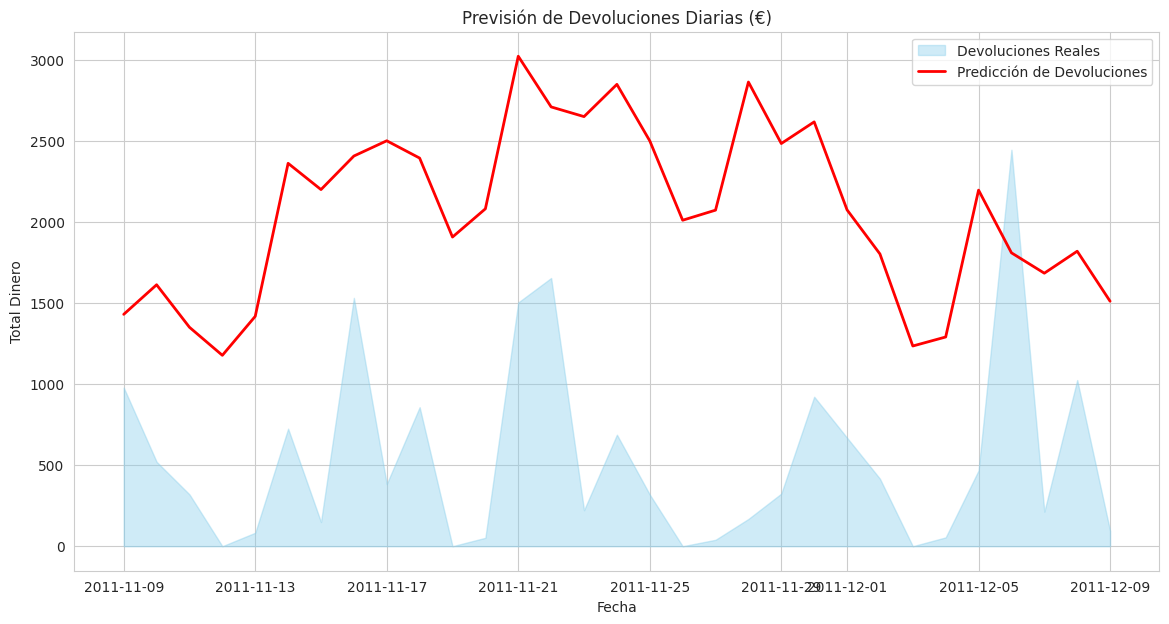

In [ ]:
# IMPORTANTE: A diferencia de los otros, aquí solo hacemos una ejecución,
# ya que para Prophet el Experimento A y B son lo mismo (solo lee la fecha).

target = 'daily_returns' # La columna que hemos creado al preprocesar datos
date_for_daily = 'date'

model = Prophet(
  daily_seasonality=False, # False, ya que chequea ventas al dia hora por hora. No tenemos esa info en nuestro dataset y metería ruido
  yearly_seasonality=True,
  weekly_seasonality=True
  )

# Lanzamos Prophet
model_prophet, forecast, preds_prophet, df_test = train_predict_prophet(df_train, df_test, target, date_for_daily, model)


Para que los resultados sean más precisos y apropiados, Prophet necesita una variable externa que le diga: "El 25 de noviembre es Black Friday!". Se hace con la funcionalidad de **Holidays** o añadiendo regresores externos (`add_regressor`).

# 1. Definir el Calendario de "Choques de Demanda" (Holidays)

In [ ]:

# Configuración de eventos para el e-commerce en 2011
from prophet.make_holidays import make_holidays_df

holidays = make_holidays_df(
    year_list=[2010, 2011],
    country='UK'
)

# Modelo Prophet MULTIPLICATIVO - MEJOR RESULTADOS

📊 Métricas para Prophet:
   - MAE:  629.68  (Error medio en dinero)
   - RMSE: 778.79 (Sensible a grandes errores/outliers)
   - R2:   -0.7883  (Capacidad predictiva 0 a 1)
------------------------------
          date  actual_returns  predicted_returns  prediction_error
343 2011-11-09          978.34             969.72              8.62
344 2011-11-10          520.65           1,034.92           -514.27
345 2011-11-11          319.48             436.71           -117.23
346 2011-11-12            0.00             140.32           -140.32
347 2011-11-13           83.10             336.27           -253.17


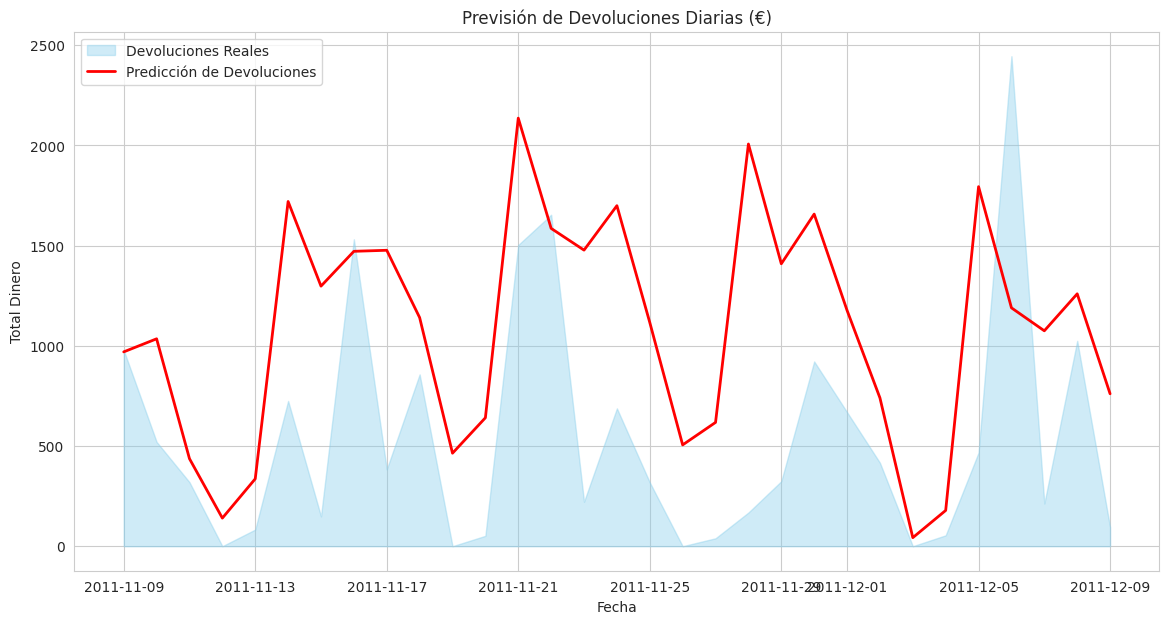

In [ ]:
# Definimos el modelo
model_prophet_multiplicative = Prophet(
  holidays=holidays,
  seasonality_mode='multiplicative',
  changepoint_prior_scale=0.1,      # Más flexible a cambios bruscos
  yearly_seasonality=True,
  weekly_seasonality=True,
  daily_seasonality=False
)

model_prophet, forecast, preds_prophet, df_test = train_predict_prophet(df_train, df_test, target, date_for_daily, model_prophet_multiplicative)

# Modelo Prophet ADITIVO

📊 Métricas para Prophet:
   - MAE:  1757.33  (Error medio en dinero)
   - RMSE: 1860.49 (Sensible a grandes errores/outliers)
   - R2:   -9.2062  (Capacidad predictiva 0 a 1)
------------------------------
          date  actual_returns  predicted_returns  prediction_error
343 2011-11-09          978.34           1,436.18           -457.84
344 2011-11-10          520.65           1,634.37         -1,113.72
345 2011-11-11          319.48           1,433.70         -1,114.22
346 2011-11-12            0.00           1,233.54         -1,233.54
347 2011-11-13           83.10           1,477.18         -1,394.08


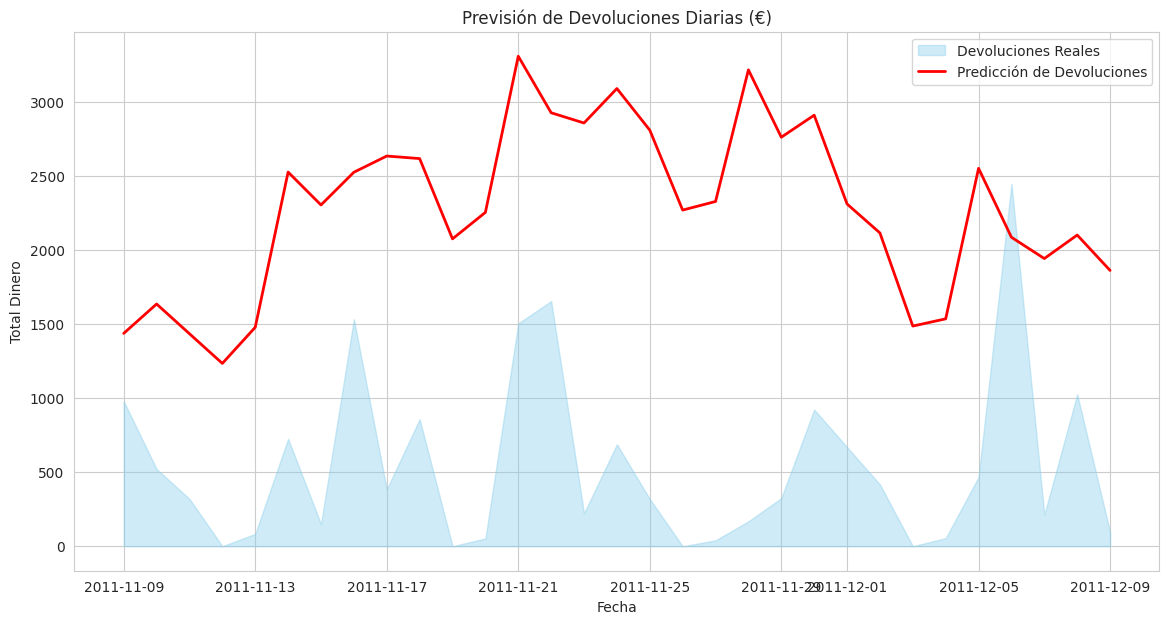

In [ ]:
# Definimos el modelo avanzado
model_prophet_adv = Prophet(
  holidays=holidays,
  seasonality_mode='additive',
  changepoint_prior_scale=0.1,        # Más flexible a cambios bruscos
  yearly_seasonality=True,
  weekly_seasonality=True,
  daily_seasonality=False
)

model_prophet, forecast, preds_prophet, df_test = train_predict_prophet(df_train, df_test, target, date_for_daily, model_prophet_adv)

In [ ]:
def train_predict_prophet_rescue(df_train, df_test, target, date, prophet_model, nombre_exp="Prophet"):
    # 1. Preparar datos (Prophet es estricto con los nombres)
    train_prophet = df_train.rename(columns={date: 'ds', target: 'y'})

    # NUEVA PARTE AÑADIDA: Crear el regresor de "memoria" (Lag 1)
    # Ensure we are working on copies to avoid SettingWithCopyWarning if df_train/df_test are views
    df_train_copy = df_train.copy()
    df_test_copy = df_test.copy()

    df_train_copy['sales_lag1'] = df_train_copy['daily_returns'].shift(1).fillna(method='bfill')
    df_test_copy['sales_lag1'] = df_test_copy['daily_returns'].shift(1).fillna(method='bfill')

    model = prophet_model

    # 3. ¡IMPORTANTE! Añadir el regresor antes del fit
    model.add_regressor('sales_lag1') # Changed model_rescue to model

    # 2. Entrenar
    model.fit(train_prophet.assign(sales_lag1=df_train_copy['sales_lag1'])) # Pass regressor to fit

    # 3. Predecir (le pasamos los días del dataframe de test)
    test_prophet = df_test_copy.rename(columns={date: 'ds'}) # Use df_test_copy
    forecast = model.predict(test_prophet[['ds', 'sales_lag1']]) # Pass the regressor to predict

    # El resultado está en la columna 'yhat'
    preds = forecast['yhat']

    df_test_modified = df_test.copy()
    df_test_modified['predicted_returns'] = preds.values # Corrected: Use .values to avoid index mismatch
    df_test_modified['actual_returns'] = df_test_modified[target] # Renombramos para claridad
    df_test_modified['prediction_error'] = df_test_modified['actual_returns'] - df_test_modified['predicted_returns']

    # --- PASO 3: Visualización y Métricas (Lo que viene después) ---

    # Metricas
    y_test = df_test_modified[target]

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    print(f"📊 Métricas para {nombre_exp}:")
    print(f"   - MAE:  {mae:.2f}  (Error medio en dinero)")
    print(f"   - RMSE: {rmse:.2f} (Sensible a grandes errores/outliers)")
    print(f"   - R2:   {r2:.4f}  (Capacidad predictiva 0 a 1)")
    print("-" * 30)

    print(df_test_modified[['date', 'actual_returns', 'predicted_returns', 'prediction_error']].head())

    # Agrupamos por día
    devol_diarias = df_test_modified.groupby(df_test_modified['date'].dt.date)[['actual_returns', 'predicted_returns']].sum()

    # Gráfica
    plt.figure(figsize=(14, 7))
    plt.fill_between(devol_diarias.index, devol_diarias['actual_returns'], color="skyblue", alpha=0.4, label='Devoluciones Reales')
    plt.plot(devol_diarias.index, devol_diarias['predicted_returns'], color="red", lw=2, label='Predicción de Devoluciones')
    plt.title("Previsión de Devoluciones Diarias (€)")
    plt.xlabel("Fecha")
    plt.ylabel("Total Dinero")
    plt.legend()
    plt.show()

    return model, forecast, preds, df_test_modified

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


📊 Métricas para Prophet:
   - MAE:  861.09  (Error medio en dinero)
   - RMSE: 949.51 (Sensible a grandes errores/outliers)
   - R2:   -1.6583  (Capacidad predictiva 0 a 1)
------------------------------
          date  actual_returns  predicted_returns  prediction_error
343 2011-11-09          978.34             997.38            -19.04
344 2011-11-10          520.65           1,090.78           -570.13
345 2011-11-11          319.48             932.78           -613.30
346 2011-11-12            0.00             520.24           -520.24
347 2011-11-13           83.10             679.94           -596.84


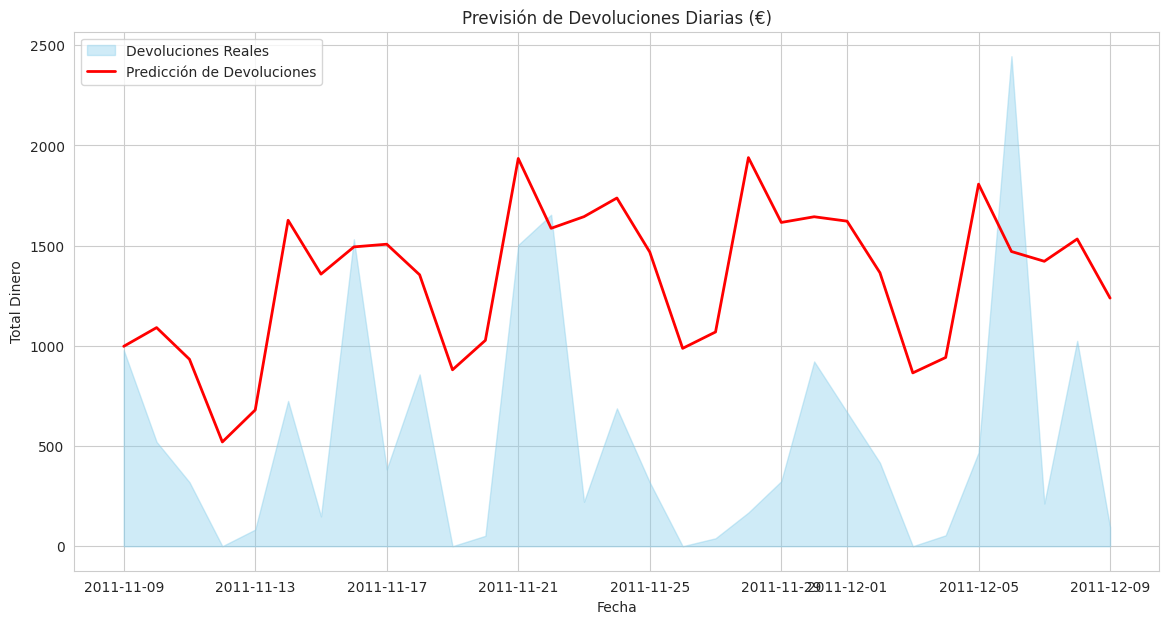

In [ ]:
model_rescue = Prophet(
    holidays=holidays,
    seasonality_mode='additive',   # Volvemos a aditivo ya que funciona mejor
    changepoint_prior_scale=0.01,   # Forzamos estabilidad
    weekly_seasonality=True,
    yearly_seasonality=True
)


model_prophet, forecast, preds_prophet, df_test = train_predict_prophet_rescue(df_train, df_test, target, date_for_daily, model_rescue)

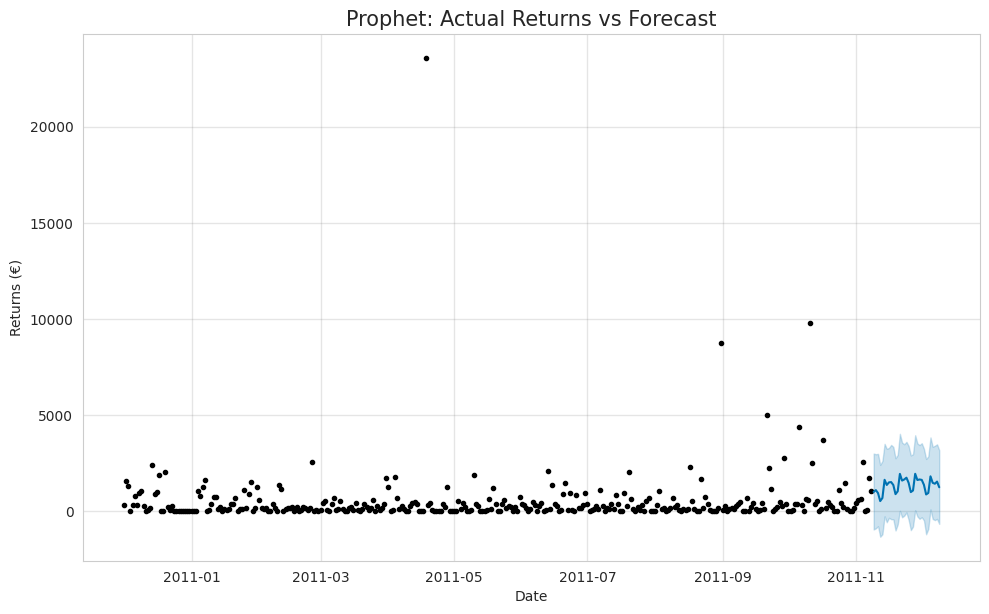

In [ ]:
from prophet.plot import plot_plotly, plot_components_plotly

# 1. Gráfico principal (Predicción con bandas de incertidumbre)
# Usamos objeto 'model_prophet' y dataframe de predicciones 'forecast'

# Gráfico estándar de Prophet (Matplotlib)
fig1 = model_prophet.plot(forecast)
plt.title("Prophet: Actual Returns vs Forecast", fontsize=15)
plt.xlabel("Date")
plt.ylabel("Returns (€)")
plt.show()



2. Descomposición de Componentes (La "Caja Negra" abierta)
Esta es, para mí, la visualización más valiosa de Prophet. Te permite ver por separado:

  - Trend: La previsión de devoluciones general. En este caso la predicción para el próximo mes. (09-11-2011 a 09-12-2011)

  - Weekly: Qué días de la semana se factura más.

  - Yearly: Se pueden apreciar los picos estacionales (Black Friday, Navidad, verano, etc.).


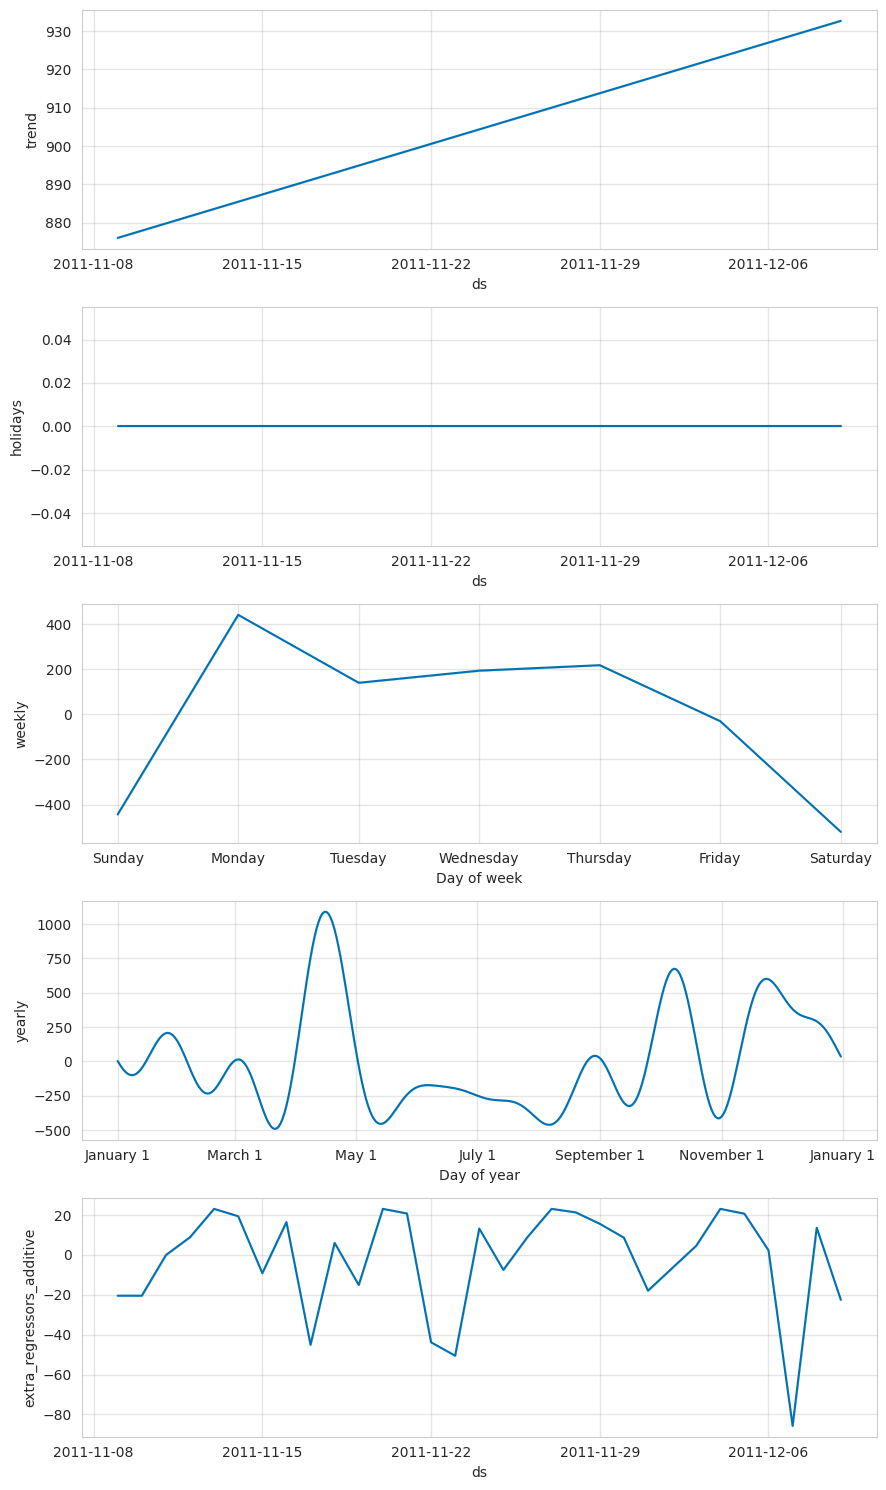

In [ ]:
# 2. Gráfico de Componentes (Tendencia y Estacionalidad)
fig2 = model_prophet.plot_components(forecast)
plt.show()

# TEST 2



In [ ]:
from prophet import Prophet

def train_prophet(
    df,
    changepoint_prior_scale,
    seasonality_prior_scale,
    seasonality_mode
):
    model = Prophet(
        growth='linear',
        changepoint_prior_scale=changepoint_prior_scale,
        seasonality_prior_scale=seasonality_prior_scale,
        seasonality_mode=seasonality_mode,
        weekly_seasonality=True,
        yearly_seasonality=True,
        daily_seasonality=False
    )

    # Estacionalidad mensual (muy útil en e-commerce)
    model.add_seasonality(
        name='monthly',
        period=30.5,
        fourier_order=5
    )

    model.fit(df)

    return model

## Modelo A (baseline robusto)

In [ ]:
train = df_train

target = 'daily_returns' # La columna que hemos creado al preprocesar datos
date_for_daily = 'date'

train = df_train.rename(columns={date_for_daily: 'ds', target: 'y'})

model_A = train_prophet(
    train,
    changepoint_prior_scale=0.05,
    seasonality_prior_scale=10,
    seasonality_mode='additive'
)

## Modelo B (captura picos de devoluciones)

In [ ]:
model_B = train_prophet(
    train,
    changepoint_prior_scale=0.3,
    seasonality_prior_scale=15,
    seasonality_mode='multiplicative'
)

## Modelo C (regularizado, evita sobreajuste)

In [ ]:
model_C = train_prophet(
    train,
    changepoint_prior_scale=0.01,
    seasonality_prior_scale=5,
    seasonality_mode='additive'
)

## Modelo D (equilibrado, normalmente ganador en e-commerce)

In [ ]:
model_D = train_prophet(
    train,
    changepoint_prior_scale=0.1,
    seasonality_prior_scale=10,
    seasonality_mode='multiplicative'
)

# ----- Validación con backtesting (solo TRAIN) -------

Usaremos cross_validation

In [ ]:
from prophet.diagnostics import cross_validation, performance_metrics

def validate_model(model):

    df_cv = cross_validation(
        model,
        initial='250 days',
        period='30 days',
        horizon='30 days'
    )

    df_perf = performance_metrics(df_cv)

    return df_perf

## Evaluar modelos

In [ ]:
models = {
    "A": model_A,
    "B": model_B,
    "C": model_C,
    "D": model_D
}

results = {}

for name, model in models.items():
    perf = validate_model(model)
    results[name] = perf['rmse'].mean()

print(results)

INFO:prophet:Making 3 forecasts with cutoffs between 2011-08-10 00:00:00 and 2011-10-09 00:00:00


  0%|          | 0/3 [00:00<?, ?it/s]

INFO:prophet:Skipping MAPE because y close to 0
INFO:prophet:Making 3 forecasts with cutoffs between 2011-08-10 00:00:00 and 2011-10-09 00:00:00


  0%|          | 0/3 [00:00<?, ?it/s]

INFO:prophet:Skipping MAPE because y close to 0
INFO:prophet:Making 3 forecasts with cutoffs between 2011-08-10 00:00:00 and 2011-10-09 00:00:00


  0%|          | 0/3 [00:00<?, ?it/s]

INFO:prophet:Skipping MAPE because y close to 0
INFO:prophet:Making 3 forecasts with cutoffs between 2011-08-10 00:00:00 and 2011-10-09 00:00:00


  0%|          | 0/3 [00:00<?, ?it/s]

INFO:prophet:Skipping MAPE because y close to 0


{'A': np.float64(1438.87424382827), 'B': np.float64(1568.3822924830645), 'C': np.float64(1292.5489446731328), 'D': np.float64(1550.4385252169031)}


# ----------  Selección del mejor modelo -------

In [ ]:
best_model_name = min(results, key=results.get)
best_model = models[best_model_name]

print("Best model:", best_model_name)

Best model: C


# ------ Predicción en TEST (lo importante) ------

Ahora sí usamos el periodo real que definimos:

In [ ]:
future = best_model.make_future_dataframe(periods=31)

forecast = best_model.predict(future)

## Filtrar solo periodo de test

In [ ]:
forecast_test = forecast[
    (forecast['ds'] >= '2011-11-09') &
    (forecast['ds'] <= '2011-12-09')
]

# ------ Evaluacion final (TEST REAL)

📊 Métricas para Prophet elegido:
   - MAE:  968.93  (Error medio en dinero)
   - RMSE: 1,067.84 (Sensible a grandes errores/outliers)
   - R2:   -2.3622  (Capacidad predictiva 0 a 1)
------------------------------
        date  actual_returns  predicted_returns  prediction_error
0 2011-11-09          978.34           1,182.97           -204.63
1 2011-11-10          520.65           1,504.60           -983.95
2 2011-11-11          319.48           1,368.69         -1,049.21
3 2011-11-12            0.00             755.41           -755.41
4 2011-11-13           83.10             645.92           -562.82


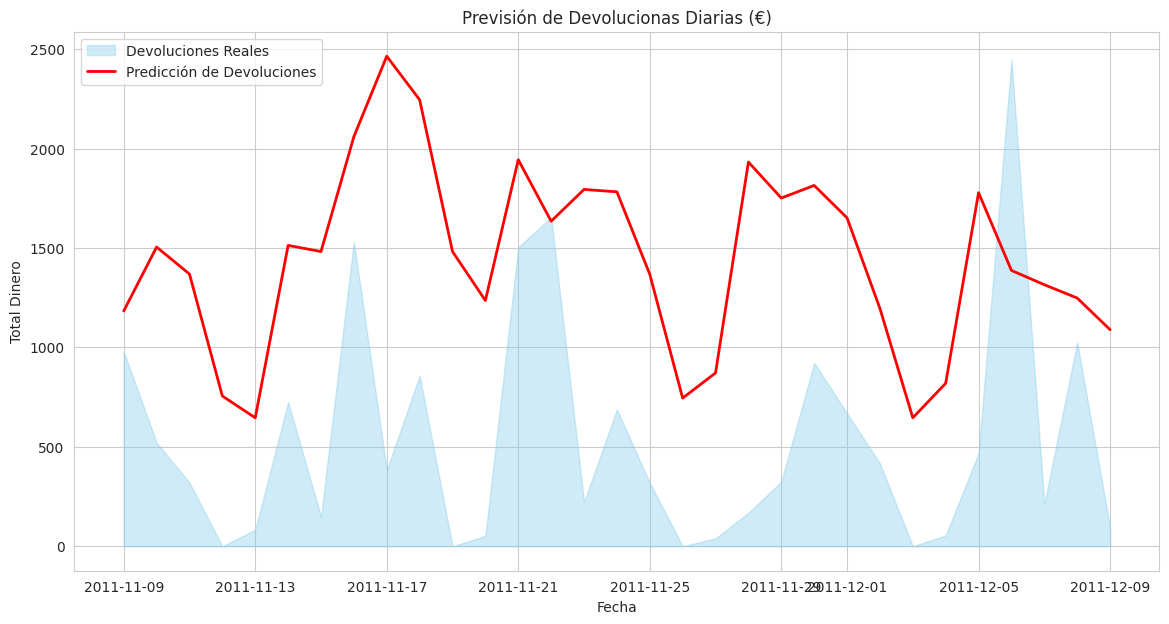

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def evaluate_test(forecast_test, test):

    # Merge forecast_test (with 'ds', 'yhat') with test (with 'date', 'daily_returns')
    # We need to explicitly map the date columns for merging and the target column for evaluation.
    df_eval = forecast_test[['ds', 'yhat']].merge(test[['date', 'daily_returns']], left_on='ds', right_on='date')

    # Rename columns for clarity and calculate prediction error
    df_eval = df_eval.rename(columns={'daily_returns': 'actual_returns', 'yhat': 'predicted_returns'})
    df_eval['prediction_error'] = df_eval['actual_returns'] - df_eval['predicted_returns']

    # Metricas
    mae = mean_absolute_error(df_eval['actual_returns'], df_eval['predicted_returns'])
    rmse = np.sqrt(mean_squared_error(df_eval['actual_returns'], df_eval['predicted_returns']))
    r2 = r2_score(df_eval['actual_returns'], df_eval['predicted_returns'])

    print(f"📊 Métricas para Prophet elegido:")
    print(f"   - MAE:  {mae:,.2f}  (Error medio en dinero)")
    print(f"   - RMSE: {rmse:,.2f} (Sensible a grandes errores/outliers)")
    print(f"   - R2:   {r2:.4f}  (Capacidad predictiva 0 a 1)")
    print("-" * 30)

    # Use 'date' instead of 'InvoiceDate' for display and grouping
    print(df_eval[['date', 'actual_returns', 'predicted_returns', 'prediction_error']].head())

    # Agrupamos por día
    devoluc_diarias = df_eval.groupby(df_eval['date'].dt.date)[['actual_returns', 'predicted_returns']].sum()

    # Gráfica
    plt.figure(figsize=(14, 7))
    plt.fill_between(devoluc_diarias.index, devoluc_diarias['actual_returns'], color="skyblue", alpha=0.4, label='Devoluciones Reales')
    plt.plot(devoluc_diarias.index, devoluc_diarias['predicted_returns'], color="red", lw=2, label='Predicción de Devoluciones')
    plt.title("Previsión de Devolucionas Diarias (€)")
    plt.xlabel("Fecha")
    plt.ylabel("Total Dinero")
    plt.legend()
    plt.show()

    return mae, rmse, df_eval

mae, rmse, df_eval = evaluate_test(forecast_test, df_test)


# Exportar mejor modelo / resultado a archivo .csv

📊 Métricas para Prophet:
   - MAE:  629.68  (Error medio en dinero)
   - RMSE: 778.79 (Sensible a grandes errores/outliers)
   - R2:   -0.7883  (Capacidad predictiva 0 a 1)
------------------------------
          date  actual_returns  predicted_returns  prediction_error
343 2011-11-09          978.34             969.72              8.62
344 2011-11-10          520.65           1,034.92           -514.27
345 2011-11-11          319.48             436.71           -117.23
346 2011-11-12            0.00             140.32           -140.32
347 2011-11-13           83.10             336.27           -253.17


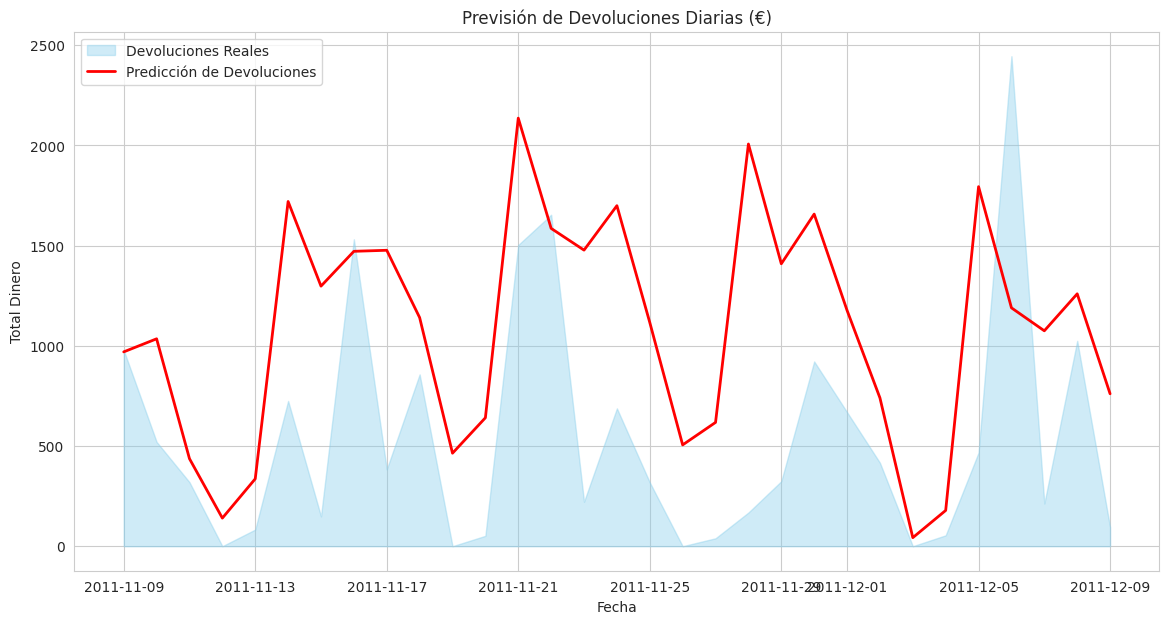

,date,daily_returns,month,day_of_month,day_of_week,is_weekend,returns_lag_1,returns_lag_7,predicted_returns,actual_returns,prediction_error
343,2011-11-09,978.34,11,9,2,0,"1,019.39",601.66,969.72,978.34,8.62
344,2011-11-10,520.65,11,10,3,0,978.34,614.75,"1,034.92",520.65,-514.27
345,2011-11-11,319.48,11,11,4,0,520.65,"2,537.17",436.71,319.48,-117.23
346,2011-11-12,0.00,11,12,5,1,319.48,0.00,140.32,0.00,-140.32
347,2011-11-13,83.10,11,13,6,1,0.00,33.94,336.27,83.10,-253.17
348,2011-11-14,724.93,11,14,0,0,83.10,"1,697.92","1,720.08",724.93,-995.15
349,2011-11-15,149.04,11,15,1,0,724.93,"1,019.39","1,297.76",149.04,"-1,148.72"
350,2011-11-16,"1,531.47",11,16,2,0,149.04,978.34,"1,471.47","1,531.47",60.00
351,2011-11-17,383.41,11,17,3,0,"1,531.47",520.65,"1,476.68",383.41,"-1,093.27"
352,2011-11-18,857.38,11,18,4,0,383.41,319.48,"1,140.92",857.38,-283.54


Predicciones exportadas correctamente a: /content/sample_data/prediccion_test_devoluciones.csv


In [ ]:
# Configuración de eventos para el e-commerce en 2011
from prophet.make_holidays import make_holidays_df

holidays = make_holidays_df(
    year_list=[2010, 2011],
    country='UK'
)


target = 'daily_returns' # La columna que hemos creado al preprocesar datos
date_for_daily = 'date'

model_prophet_multiplicative = Prophet(
  holidays=holidays,
  seasonality_mode='multiplicative',
  changepoint_prior_scale=0.1,      # Más flexible a cambios bruscos
  yearly_seasonality=True,
  weekly_seasonality=True,
  daily_seasonality=False
)

model_prophet, forecast, preds_prophet, df_test = train_predict_prophet(df_train, df_test, target, date_for_daily, model_prophet_multiplicative)

display(df_test)

path_predictions_csv = '/content/sample_data/prediccion_test_devoluciones.csv'

df_test.to_csv(path_predictions_csv, index=False)
print(f"Predicciones exportadas correctamente a: {path_predictions_csv}")


--- 3. EVALUACIÓN Y VISUALIZACIÓN DEL MES DE TEST con time series split ---
          date  daily_returns  month  day_of_month  day_of_week  is_weekend  returns_lag_1  returns_lag_7  \
343 2011-11-09         978.34     11             9            2           0       1,019.39         601.66   
344 2011-11-10         520.65     11            10            3           0         978.34         614.75   
345 2011-11-11         319.48     11            11            4           0         520.65       2,537.17   
346 2011-11-12           0.00     11            12            5           1         319.48           0.00   
347 2011-11-13          83.10     11            13            6           1           0.00          33.94   

     predicted_returns  actual_returns  prediction_error  
343             969.72          978.34              8.62  
344           1,034.92          520.65           -514.27  
345             436.71          319.48           -117.23  
346             140.32          

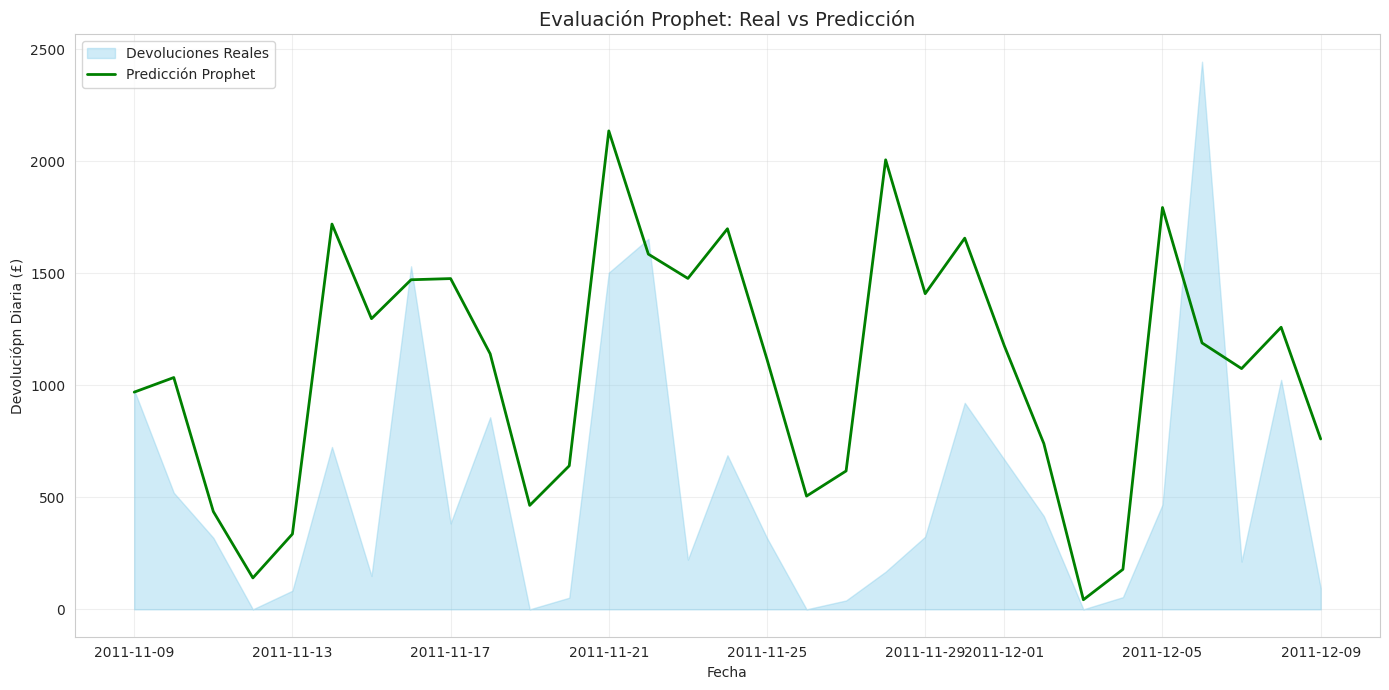

In [ ]:
print("\n--- 3. EVALUACIÓN Y VISUALIZACIÓN DEL MES DE TEST con time series split ---")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_prophet_with_transparency(df_test):
    print(df_test.head())

    # 2. Preparamos el dataframe de evaluación
    df_eval = df_test.copy()

    # Ensure 'date' column is datetime type for plotting
    df_eval['date'] = pd.to_datetime(df_eval['date'])

    df_eval['prediction_error'] = df_eval['actual_returns'] - df_eval['predicted_returns']

    # ESCENARIO A: TEST COMPLETO
    mae_full = mean_absolute_error(df_eval['actual_returns'], df_eval['predicted_returns'])
    rmse_full = np.sqrt(mean_squared_error(df_eval['actual_returns'], df_eval['predicted_returns']))
    r2_full = r2_score(df_eval['actual_returns'], df_eval['predicted_returns'])

    print("\n[ ESCENARIO A ] MÉTRICAS CON EL TEST COMPLETO (Incluyendo 14-Nov)")
    print(f"   - MAE:  £{mae_full:,.2f}")
    print(f"   - RMSE: £{rmse_full:,.2f}")
    print(f"   - R2:   {r2_full:.4f}")

    # ESCENARIO B: EXCLUSIÓN DE VENTA AL POR MAYOR (14 de Noviembre) tambien quitamos las devoluciones de ese dia
    fecha_anomala = '2011-11-14'
    # Filtramos comparando strings de fecha
    df_eval_corregido = df_eval[df_eval['date'].dt.strftime('%Y-%m-%d') != fecha_anomala]

    mae_corr = mean_absolute_error(df_eval_corregido['actual_returns'], df_eval_corregido['predicted_returns'])
    rmse_corr = np.sqrt(mean_squared_error(df_eval_corregido['actual_returns'], df_eval_corregido['predicted_returns']))
    r2_corr = r2_score(df_eval_corregido['actual_returns'], df_eval_corregido['predicted_returns'])

    print(f"\n[ ESCENARIO B ] MÉTRICAS CORREGIDAS (Excluyendo pedido mayorista del {fecha_anomala})")
    print(f"   - MAE:  £{mae_corr:,.2f}  (Mejora de £{mae_full - mae_corr:,.2f})")
    print(f"   - RMSE: £{rmse_corr:,.2f}  (Mejora de £{rmse_full - rmse_corr:,.2f})")
    print(f"   - R2:   {r2_corr:.4f}")
    print("-" * 80)


    #Exportar a CSV
    path_predictions_csv = '/content/sample_data/prediccion_test_devoluciones-excluido-pico-ventas.csv'
    df_eval_corregido.to_csv(path_predictions_csv, index=False)
    print(f"Predicciones exportadas correctamente a: {path_predictions_csv}")

    # VISUALIZACIÓN
    plt.figure(figsize=(14, 7))

    # Pintamos la realidad y la predicción
    plt.fill_between(df_eval['date'], df_eval['actual_returns'], color="skyblue", alpha=0.4, label='Devoluciones Reales')
    plt.plot(df_eval['date'], df_eval['predicted_returns'], color="green", lw=2, label='Predicción Prophet')


    plt.title("Evaluación Prophet: Real vs Predicción", fontsize=14)
    plt.xlabel("Fecha")
    plt.ylabel("Devoluciópn Diaria (£)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return df_eval, df_eval_corregido


df_eval, df_eval_corregido = evaluate_prophet_with_transparency(df_test)

